In [1]:
from datasets import Dataset, DatasetDict
import json

def load_jsonl_to_datasetdict(file_path, split_name="train"):
    """
    Load a JSONL file and convert it into a Hugging Face DatasetDict.
    
    Args:
        file_path (str): Path to the JSONL file.
        split_name (str): Name of the split (default is "train").
    
    Returns:
        DatasetDict: A Hugging Face DatasetDict containing the data.
    """
    # Load JSONL data
    data = []
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            data.append(json.loads(line.strip()))
    
    # Create a Hugging Face Dataset from the list of dictionaries
    dataset = Dataset.from_list(data)
    
    # Wrap it into a DatasetDict with the specified split name
    dataset_dict = DatasetDict({split_name: dataset})
    return dataset_dict

# Example usage
file_path = '/shared_data0/weiqiuy/nsf-awards/data/dmr_nsf_awards_with_claims.jsonl'  # Replace with your JSONL file path
dataset_dict = load_jsonl_to_datasetdict(file_path, split_name="train")

# Inspect the dataset
print(dataset_dict)
print(dataset_dict["train"][0].keys())  # Print the first entry

DatasetDict({
    train: Dataset({
        features: ['award_id', 'technical_abstract', 'non_technical_abstract', 'verifiable_claims', 'investigation_proposals', 'award_year', 'division', 'directorate', 'title', 'publications'],
        num_rows: 16042
    })
})
dict_keys(['award_id', 'technical_abstract', 'non_technical_abstract', 'verifiable_claims', 'investigation_proposals', 'award_year', 'division', 'directorate', 'title', 'publications'])


In [2]:
import numpy as np

for field in dataset_dict['train'][0].keys():
    # Get field values
    field_values = dataset_dict["train"][field]
    
    # Normalize values: handle None and complex types
    hashable_values = [
        str(value) if isinstance(value, (dict, list)) else ("None" if value is None else value)
        for value in field_values
    ]

    # Compute unique values and print results
    unique_count = len(np.unique(hashable_values))
    total_count = len(field_values)
    print(field, unique_count, total_count)
    if field == 'title':
        break


award_id 16030 16042
technical_abstract 14998 16042
non_technical_abstract 12086 16042
verifiable_claims 15524 16042
investigation_proposals 15605 16042
award_year 42 16042
division 2 16042
directorate 2 16042
title 13819 16042


In [3]:
# Count entries where title is None
none_title_count = sum(1 for title in dataset_dict["train"]['title'] if title is None)

# Print the result
print(f"Number of entries where title is None: {none_title_count}")


Number of entries where title is None: 424


In [4]:
from collections import defaultdict

def filter_records(dataset, fields_to_check, title_field="title"):
    """
    Remove all records with duplicates in the specified fields or None in the title field.

    Args:
        dataset (Dataset): A Hugging Face Dataset object.
        fields_to_check (list): List of fields to check for duplicates.
        title_field (str): The field to check for None values (default: "title").
    
    Returns:
        list: Filtered dataset with records removed based on the criteria.
    """
    # Identify duplicates for specified fields
    duplicate_indices = set()
    for field in fields_to_check:
        # Group by field values
        value_to_indices = defaultdict(list)
        for idx, entry in enumerate(dataset):
            # Ensure field values are hashable
            field_value = entry[field]
            if field_value == '':
                continue
            if isinstance(field_value, list):
                field_value = tuple(field_value)
            elif isinstance(field_value, dict):
                field_value = frozenset(field_value.items())

            value_to_indices[field_value].append(idx)

        # Mark all indices of duplicates
        for indices in value_to_indices.values():
            if len(indices) > 1:  # Duplicates found
                duplicate_indices.update(indices)
                
    # for field in fields_to_remove_empty:
    #     # Group by field values
    #     for idx, entry in enumerate(dataset):
    #         # Ensure field values are hashable
    #         field_value = entry[field]
    #         if field_value == '':
    #             duplicate_indices.add(idx)
    
    # Identify records with None in the title field
    none_title_indices = {idx for idx, entry in enumerate(dataset) if entry[title_field] is None}

    # Combine all indices to remove
    indices_to_remove = duplicate_indices.union(none_title_indices)

    # Filter the dataset
    filtered_dataset = [entry for idx, entry in enumerate(dataset) if idx not in indices_to_remove]

    return filtered_dataset

# Fields to check for duplicates
fields_to_check = ["award_id", "verifiable_claims", "investigation_proposals", "technical_abstract", "non_technical_abstract"]
# fields_to_remove_empty = ["technical_abstract", "non_technical_abstract"]

# Apply the filtering
filtered_dataset = filter_records(dataset_dict["train"], fields_to_check)

# Print the size of the original and filtered dataset
print(f"Original dataset size: {len(dataset_dict['train'])}")
print(f"Filtered dataset size: {len(filtered_dataset)}")


Original dataset size: 16042
Filtered dataset size: 13675


In [5]:
def find_matching_abstracts(dataset, tech_field="technical_abstract", non_tech_field="non_technical_abstract"):
    """
    Find indices where the technical_abstract is equal to the non_technical_abstract.

    Args:
        dataset (Dataset): A Hugging Face Dataset object.
        tech_field (str): The field for technical abstract (default: "technical_abstract").
        non_tech_field (str): The field for non-technical abstract (default: "non_technical_abstract").
    
    Returns:
        list: Indices where the technical and non-technical abstracts are identical.
    """
    matching_indices = [idx for idx, entry in enumerate(dataset) if entry[tech_field] == entry[non_tech_field]]
    return matching_indices

# Get indices where the abstracts are identical
matching_indices = find_matching_abstracts(filtered_dataset)

# Print the results
print(f"Number of records where technical_abstract == non_technical_abstract: {len(matching_indices)}")
print(f"Matching indices: {matching_indices[:10]}")  # Print first 10 matches for reference


Number of records where technical_abstract == non_technical_abstract: 12
Matching indices: [1289, 2882, 3463, 4963, 5206, 5274, 5711, 5872, 8277, 10045]


In [10]:
def find_empty_ip(dataset, field='investigation_proposals'):
    """
    Find indices where the technical_abstract is equal to the non_technical_abstract.

    Args:
        dataset (Dataset): A Hugging Face Dataset object.
        tech_field (str): The field for technical abstract (default: "technical_abstract").
        non_tech_field (str): The field for non-technical abstract (default: "non_technical_abstract").
    
    Returns:
        list: Indices where the technical and non-technical abstracts are identical.
    """
    empty_indices = [idx for idx, entry in enumerate(dataset) if entry[field] == '']
    return empty_indices

# Get indices where the abstracts are identical
empty_indices = find_empty_ip(filtered_dataset)

# Print the results
print(f"Number of records where ip is empty: {len(empty_indices)}")
print(f"Empty indices: {empty_indices[:10]}")  # Print first 10 matches for reference

# Get indices where the abstracts are identical
empty_indices = find_empty_ip(filtered_dataset, field='verifiable_claims')

# Print the results
print(f"Number of records where verifiable_claims is empty: {len(empty_indices)}")
print(f"Empty indices: {empty_indices[:10]}")  # Print first 10 matches for reference


Number of records where ip is empty: 0
Empty indices: []
Number of records where verifiable_claims is empty: 0
Empty indices: []


In [7]:
filtered_dataset[2490]['technical_abstract'], filtered_dataset[2490]['non_technical_abstract']

('The team plans to use video microscopy and Monte Carlo simulations to study two sets of related questions in condensed matter physics: (1) What is the microscopic mechanism in the recently discovered 2D colloidal glasses of anisotropic particles? (2) Does an array of edge dislocations formed along a low-angle grain boundary in a 2D colloidal crystal undergo a finite temperature phase transition and what happens to the phase transition when there are impurity particles in the hosting 2D crystal?  The underlying fundamental question is how phases of matter and phase transitions are impacted by disorder.  The first project will investigate the physical mechanism of a two-step 2D colloidal glass transition of rods. The proposed experiments will be used to distinguish various competing scenarios of the glass transition in 2D. The second project is to study a possible novel phase transition in an array of edge dislocations formed along a low-angle grain boundary in a 2D colloidal crystal a

In [8]:
filtered_dataset_rm_matched_technontech = [filtered_dataset[i] for i in range(len(filtered_dataset)) if i not in matching_indices]
print(f"Original dataset size: {len(filtered_dataset)}")
print(f"Filtered dataset size: {len(filtered_dataset_rm_matched_technontech)}")

Original dataset size: 13675
Filtered dataset size: 13663


In [9]:
import numpy as np

filtered_dataset_ = Dataset.from_list(filtered_dataset_rm_matched_technontech)
    
# Wrap it into a DatasetDict with the specified split name
filtered_dataset_dict = DatasetDict({'train': filtered_dataset_})

for field in filtered_dataset_dict['train'][0].keys():
    # Get field values
    field_values = filtered_dataset_dict["train"][field]
    
    # Normalize values: handle None and complex types
    hashable_values = [
        str(value) if isinstance(value, (dict, list)) else ("None" if value is None else value)
        for value in field_values
    ]

    # Compute unique values and print results
    unique_count = len(np.unique(hashable_values))
    total_count = len(field_values)
    print(field, unique_count, total_count)
    if field == 'title':
        break

award_id 13663 13663
technical_abstract 13631 13663
non_technical_abstract 10846 13663
verifiable_claims 13663 13663
investigation_proposals 13663 13663
award_year 41 13663
division 1 13663
directorate 1 13663
title 12744 13663


In [ ]:
from collections import defaultdict
from strsimpy.cosine import Cosine


def compute_bleu_score(text1, text2):
    """
    Compute the BLEU score between two texts using sacrebleu.

    Args:
        text1 (str): The reference text.
        text2 (str): The hypothesis text.

    Returns:
        float: The BLEU score between the two texts.
    """
    references = [text1]
    hypothesis = text2
    bleu = sacrebleu.sentence_bleu(hypothesis, references)
    return bleu.score

def jaccard_similarity(text1, text2):
    set1 = set(text1.split())
    set2 = set(text2.split())
    intersection = set1.intersection(set2)
    union = set1.union(set2)
    return len(intersection) / len(union)

# # Example usage:
# similarity = jaccard_similarity("The quick brown fox", "The quick red fox")
# print(similarity)  # Value between 0 and 1


def preprocess_abstracts_for_datasetdict(dataset_dict):
    """
    Preprocess technical_abstract and non_technical_abstract fields in a DatasetDict
    by removing specific phrases and stripping whitespace.

    Args:
        dataset_dict (DatasetDict): A Hugging Face DatasetDict object.
    
    Returns:
        DatasetDict: A new DatasetDict with preprocessed fields.
    """
    def preprocess_entry(entry):
        # Modify technical_abstract
        if "technical_abstract" in entry and entry["technical_abstract"] is not None:
            entry["technical_abstract"] = entry["technical_abstract"].replace(
                "TECHNICAL SUMMARY:", "").replace(
                "TECHNICAL SUMMARY", "").replace('Technical:', '').strip()
        
        # Modify non_technical_abstract
        if "non_technical_abstract" in entry and entry["non_technical_abstract"] is not None:
            entry["non_technical_abstract"] = entry["non_technical_abstract"].replace(
                "NON-TECHNICAL SUMMARY:", "").replace(
                "NON-TECHNICAL SUMMARY", "").replace('Non-technical:', '').strip()
        
        return entry

    # Apply the preprocessing to all splits in the DatasetDict
    return dataset_dict.map(preprocess_entry)
from collections import defaultdict
from tqdm import tqdm

def filter_records_with_jaccard_duplicates(dataset, fields_to_check, keep_first_fields, 
                                           title_field="title", sim_threshold=0.9):
    """
    Remove all records with duplicates in specified fields but keep the first non-empty for certain fields.
    Treat near-duplicate technical_abstract/non_technical_abstract as duplicates based on Jaccard similarity.

    Args:
        dataset (Dataset): A Hugging Face Dataset object.
        fields_to_check (list): List of fields to check for duplicates.
        keep_first_fields (list): Fields where the first non-empty duplicate should be kept.
        title_field (str): The field to check for None values (default: "title").
        sim_threshold (float): Jaccard similarity score threshold above which entries are considered duplicates.

    Returns:
        list: Filtered dataset with records removed or retained based on the criteria.
    """
    duplicate_indices = set()
    keep_first_indices = set()

    # Group records by field values
    for field in fields_to_check:
        value_to_indices = defaultdict(list)
        for idx, entry in enumerate(dataset):
            field_value = entry[field]
            if isinstance(field_value, list):
                field_value = tuple(field_value)
            elif isinstance(field_value, dict):
                field_value = frozenset(field_value.items())
            value_to_indices[field_value].append(idx)

        for indices in value_to_indices.values():
            if len(indices) > 1:
                if field in keep_first_fields:
                    for idx in indices:
                        entry = dataset[idx]
                        if (entry.get("technical_abstract", "") not in [None, ""] and
                                entry.get("non_technical_abstract", "") not in [None, ""]):
                            keep_first_indices.add(idx)
                            break
                    duplicate_indices.update(set(indices) - keep_first_indices)
                else:
                    duplicate_indices.update(indices)
                    
    # cosine = Cosine(10)
#     p0 = cosine.get_profile(s0)
# p1 = cosine.get_profile(s1)

    def extract_ngrams(text, n):
        """
        Extract n-grams from a given text.

        Parameters:
            text (str): The input string.
            n (int): The number of words per n-gram.

        Returns:
            List[List[str]]: A list where each element is a list of n words (an n-gram).
        """
        # Split the text into words based on spaces
        tokens = text.split()

        # Generate n-grams using list comprehension
        ngrams = [' '.join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

        return ngrams

    # Precompute token sets for Jaccard similarity
    # precomputed_embedding = {
    #     i: cosine.get_profile(entry[field]).keys() for field in ["technical_abstract", "non_technical_abstract"]
    #     for i, entry in enumerate(dataset) if field in entry and entry[field]
    # }
    precomputed_token_sets = {
        i: set(extract_ngrams(entry[field], 3)) for field in ["technical_abstract", "non_technical_abstract"]
        for i, entry in enumerate(dataset) if field in entry and entry[field]
    }

    # Check for near-duplicates using Jaccard similarity
    for field in ["technical_abstract", "non_technical_abstract"]:
        token_sets = {
            i: precomputed_token_sets[i] for i in range(len(dataset)) if i not in duplicate_indices
        }
        checked_pairs = set()
        for i, tokens1 in tqdm(token_sets.items(), desc=f"Checking {field} for near-duplicates"):
            for j, tokens2 in token_sets.items():
                if j <= i or (i, j) in checked_pairs or (j, i) in checked_pairs:
                    continue
                checked_pairs.add((i, j))
                
                # similarity = cosine.similarity_profiles(embed1, embed2)
                # print(similarity)
                # similarity = len(embed1 & embed2) / len(embed1 | embed2)
                similarity = len(tokens1 & tokens2) / len(tokens1 | tokens2)
                if similarity > sim_threshold:
                    print(similarity)
                    duplicate_indices.add(j)

    # Identify records with None or empty title
    none_or_empty_title_indices = {
        idx for idx, entry in enumerate(dataset)
        if entry[title_field] is None or entry[title_field] == ""
    }

    # Identify records with empty technical or non-technical abstract
    empty_abstract_indices = {
        idx for idx, entry in enumerate(dataset)
        if entry.get("technical_abstract", "") in [None, ""] or
           entry.get("non_technical_abstract", "") in [None, ""]
    }

    # Combine all indices to remove, excluding those explicitly kept
    indices_to_remove = (
        duplicate_indices.union(none_or_empty_title_indices, empty_abstract_indices)
    ) - keep_first_indices

    # Filter the dataset
    filtered_dataset = [entry for idx, entry in enumerate(dataset) if idx not in indices_to_remove]

    return filtered_dataset



# Preprocess abstracts
dataset_dict_clean = preprocess_abstracts_for_datasetdict(dataset_dict)

# Fields to check for duplicates
fields_to_check = ["award_id", "technical_abstract", "non_technical_abstract"]
keep_first_fields = ["technical_abstract"]

# Apply the filtering
filtered_dataset2 = filter_records_with_jaccard_duplicates(dataset_dict_clean["train"], fields_to_check, keep_first_fields)

# Print the size of the original and filtered dataset
print(f"Original dataset size: {len(dataset_dict['train'])}")
print(f"Filtered dataset size: {len(filtered_dataset2)}")



Map:   0%|          | 0/16042 [00:00<?, ? examples/s]

Checking technical_abstract for near-duplicates:   1%|          | 66/11181 [00:10<29:25,  6.30it/s] 

0.9239543726235742


Checking technical_abstract for near-duplicates:   2%|▏         | 196/11181 [00:29<25:55,  7.06it/s]

0.9411764705882353


...

Checking technical_abstract for near-duplicates:  83%|████████▎ | 9255/11181 [13:02<00:34, 55.69it/s]

0.9609375


Checking technical_abstract for near-duplicates:  97%|█████████▋| 10896/11181 [13:20<00:01, 223.61it/s]

1.0


Checking technical_abstract for near-duplicates: 100%|██████████| 11181/11181 [13:21<00:00, 13.95it/s] 
Checking non_technical_abstract for near-duplicates:  38%|███▊      | 4264/11133 [08:23<10:19, 11.08it/s]  

In [53]:
def extract_ngrams(text, n):
    """
    Extract n-grams from a given text.

    Parameters:
        text (str): The input string.
        n (int): The number of words per n-gram.

    Returns:
        List[List[str]]: A list where each element is a list of n words (an n-gram).
    """
    # Split the text into words based on spaces
    tokens = text.split()

    # Generate n-grams using list comprehension
    ngrams = [' '.join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

    return ngrams

extract_ngrams("TECHNICAL ABSTRACT: This award provides partial support for the International Symposium on Cluster and Nanomaterials in Richmond Virginia, on October 26-29, 2015. This symposium brings together a variety of researchers from academia, national laboratories, and industry, belonging to diverse disciplines: physics, chemistry, biology, materials science, engineering, and medicine. The focus of the symposium is on the important role that clusters and nanostructures play within the energy and life sciences. In particular, central topics to be covered include the efficient storage and conversion of alternative energy sources such as solar power and hydrogen; bioactive, bioresponsive, and biomimetic materials; nanotoxicity; bioengineering and regenerative medicine. Topics related to both areas such as reactions, catalysis, electronic, optical, and magnetic properties will also be featured. NSF support will enable the participation of 30 contributors, who might not otherwise be able to attend. Half of the requested funds are destined for the support of young researchers.", 3)[:10]

['TECHNICAL ABSTRACT: This',
 'ABSTRACT: This award',
 'This award provides',
 'award provides partial',
 'provides partial support',
 'partial support for',
 'support for the',
 'for the International',
 'the International Symposium',
 'International Symposium on']

In [14]:
from strsimpy.qgram import QGram

qgram = QGram(2)
print(qgram.distance('ABCD', 'ABCE'))

2


In [25]:
from strsimpy.cosine import Cosine

cosine = Cosine(3)
s0 = 'My first string'
s1 = 'My other string...'
p0 = cosine.get_profile(s0)
p1 = cosine.get_profile(s1)
print(cosine.similarity_profiles(p0, p1))

0.41602514716892186


In [35]:
s0 = 'TECHNICAL ABSTRACT: This award provides partial support for the International Symposium on Cluster and Nanomaterials in Richmond Virginia, on October 26-29, 2015. This symposium brings together a variety of researchers from academia, national laboratories, and industry, belonging to diverse disciplines: physics, chemistry, biology, materials science, engineering, and medicine. The focus of the symposium is on the important role that clusters and nanostructures play within the energy and life sciences. In particular, central topics to be covered include the efficient storage and conversion of alternative energy sources such as solar power and hydrogen; bioactive, bioresponsive, and biomimetic materials; nanotoxicity; bioengineering and regenerative medicine. Topics related to both areas such as reactions, catalysis, electronic, optical, and magnetic properties will also be featured. NSF support will enable the participation of 30 contributors, who might not otherwise be able to attend. Half of the requested funds are destined for the support of young researchers.'
s1 = 'This award provides partial support for the International Symposium on Cluster and Nanomaterials in Richmond Virginia, on October 26-29, 2015. This symposium brings together a variety of researchers from academia, national laboratories, and industry, belonging to diverse disciplines: physics, chemistry, biology, materials science, engineering, and medicine. The focus of the symposium is on the important role that clusters and nanostructures play within the energy and life sciences. In particular, central topics to be covered include the efficient storage and conversion of alternative energy sources such as solar power and hydrogen; bioactive, bioresponsive, and biomimetic materials; nanotoxicity; bioengineering and regenerative medicine. Topics related to both areas such as reactions, catalysis, electronic, optical, and magnetic properties will also be featured. NSF support will enable the participation of 30 contributors, who might not otherwise be able to attend. Half of the requested funds are destined for the support of young researchers.'
cosine = Cosine(10)
p0 = cosine.get_profile(s0)
p1 = cosine.get_profile(s1)
print(cosine.similarity_profiles(p0, p1))

0.9908254941296936


In [36]:
qgram = QGram(2)
print(qgram.distance(s0, s1))

20


In [23]:
p1

{'My ': 1,
 'y o': 1,
 ' ot': 1,
 'oth': 1,
 'the': 1,
 'her': 1,
 'er ': 1,
 'r s': 1,
 ' st': 1,
 'str': 1,
 'tri': 1,
 'rin': 1,
 'ing': 1,
 'ng.': 1,
 'g..': 1,
 '...': 1}

In [91]:
def filter_equal_abstracts(dataset, tech_field="technical_abstract", non_tech_field="non_technical_abstract", threshold=0.9, ngram=30):
    """
    Remove records where the technical_abstract is exactly equal to the non_technical_abstract.

    Args:
        dataset (Dataset): A Hugging Face Dataset object.
        tech_field (str): The field for technical abstract (default: "technical_abstract").
        non_tech_field (str): The field for non-technical abstract (default: "non_technical_abstract").

    Returns:
        list: Filtered dataset with records removed where tech and non-tech abstracts are identical.
    """
    cosine = Cosine(ngram)
    filtered_dataset = [
        entry for entry in tqdm(dataset) if cosine.similarity_profiles(cosine.get_profile(entry[tech_field]), cosine.get_profile(entry[non_tech_field])) <= threshold
    ]
    # filtered_dataset = [
    #     entry for entry in dataset if entry[tech_field] != entry[non_tech_field]
    # ]
    filtered_out_dataset = [
        (entry, cosine.similarity_profiles(cosine.get_profile(entry[tech_field]), cosine.get_profile(entry[non_tech_field]))) for entry in tqdm(dataset) if cosine.similarity_profiles(cosine.get_profile(entry[tech_field]), cosine.get_profile(entry[non_tech_field])) > threshold
    ]
    return filtered_dataset, filtered_out_dataset

# Apply the filtering
filtered_dataset3, filtered_out_dataset = filter_equal_abstracts(filtered_dataset2, threshold=0.6, ngram=10)

# Print the size of the filtered dataset
print(f"Filtered dataset size after removing identical abstracts: {len(filtered_dataset3)}")

100%|██████████| 11569/11569 [00:09<00:00, 1199.45it/s]

Filtered dataset size after removing identical abstracts: 11141


Computing similarities: 100%|██████████| 11569/11569 [00:09<00:00, 1231.45it/s]


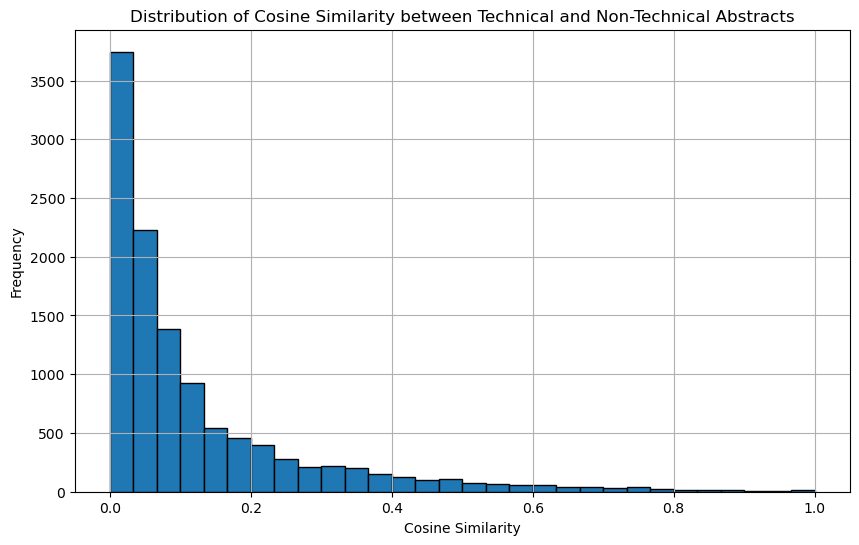

In [90]:
import matplotlib.pyplot as plt
from tqdm import tqdm

# Assuming Cosine is defined elsewhere; for example:
# from my_similarity_module import Cosine

def compute_similarities(dataset, tech_field="technical_abstract", non_tech_field="non_technical_abstract"):
    """
    Computes the cosine similarity between the technical and non-technical abstracts for each entry in the dataset.
    
    Args:
        dataset (Dataset): A Hugging Face Dataset object.
        tech_field (str): The field name for technical abstracts.
        non_tech_field (str): The field name for non-technical abstracts.
    
    Returns:
        list: A list of cosine similarity scores.
    """
    cosine = Cosine(10)
    similarities = []
    for entry in tqdm(dataset, desc="Computing similarities"):
        tech_profile = cosine.get_profile(entry[tech_field])
        nontech_profile = cosine.get_profile(entry[non_tech_field])
        similarity = cosine.similarity_profiles(tech_profile, nontech_profile)
        similarities.append(similarity)
    return similarities

# Compute similarities for the dataset
similarity_scores = compute_similarities(filtered_dataset2)

# Plot the histogram of similarity scores
plt.figure(figsize=(10, 6))
plt.hist(similarity_scores, bins=30, edgecolor='black')
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.title("Distribution of Cosine Similarity between Technical and Non-Technical Abstracts")
plt.grid(True)
plt.show()


In [93]:
# sorted(filtered_out_dataset, key=lambda x:x[1])

In [95]:
import numpy as np

filtered_dataset3_ = Dataset.from_list(filtered_dataset3)
    
# Wrap it into a DatasetDict with the specified split name
filtered_dataset3_dict = DatasetDict({'train': filtered_dataset3_})

for field in filtered_dataset3_dict['train'][0].keys():
    # Get field values
    field_values = filtered_dataset3_dict["train"][field]
    
    # Normalize values: handle None and complex types
    hashable_values = [
        str(value) if isinstance(value, (dict, list)) else ("None" if value is None else value)
        for value in field_values
    ]

    # Compute unique values and print results
    unique_count = len(np.unique(hashable_values))
    total_count = len(field_values)
    print(field, unique_count, total_count)


award_id 11141 11141
technical_abstract 11141 11141
non_technical_abstract 11141 11141
verifiable_claims 11141 11141
investigation_proposals 11140 11141
award_year 40 11141
division 2 11141
directorate 2 11141
title 10628 11141
publications 2187 11141


In [98]:
# Define the target title string
target_title = "REU Site: Computational Methods with applications in Materials Science"

# Filter the dataset for cases where the title equals the target title
target_cases = filtered_dataset3_dict["train"].filter(lambda x: x["title"] == target_title)

# Print the filtered cases
print(target_cases)


Filter:   0%|          | 0/11141 [00:00<?, ? examples/s]

Dataset({
    features: ['award_id', 'technical_abstract', 'non_technical_abstract', 'verifiable_claims', 'investigation_proposals', 'award_year', 'division', 'directorate', 'title', 'publications'],
    num_rows: 2
})


In [101]:
for x in target_cases:
    print(x['technical_abstract'], x['non_technical_abstract'])

The student participants recruited for this REU spend 10 weeks over the summer in multidisciplinary research with faculty mentors in Mathematics, Statistics, Physics, Chemistry, and Engineering from the CCS. The students are first trained in the basic science and computational techniques necessary for their research projects. Additional training activities improve the participants' computational skills and written and oral presentation skills.  The research projects fall into two general areas: materials simulation and design, and computational data analysis applied to materials. Specific projects include (1) modeling of superfluorescence; (2) electron-electron correlation; (3) machine learning prediction of interatomic forces; (4) multifunctional materials design; (5) numerical methods for time-dependent problems; (6) simulation and design of self-assembled gels; (7) optical properties of polycyclic aromatic hydrocarbons; (8) continuous data assimilation; (9) image denoising and segme

In [114]:
for i in [33, 3014, 5281, 6947, 7143, 9838][:2]: # make sure these ones with same title do have non-repeating TECHNICAL/NONTECHNICAL
    x = filtered_dataset3_dict['train'][i]
    print('TECHNICAL', x['technical_abstract'])
    print('------')
    print('NON-TECHNICAL', x['non_technical_abstract'])
    print('======')

TECHNICAL This award supports theoretical and computational research and education towards understanding the electronic, transport, optical, and magnetic properties of materials and nanostructures at the microscopic level by performing first-principles quantum calculations. The research is grouped into three topical areas of condensed matter physics and materials science: 1) novel phases and structures of materials; 2) optical and spin physics of reduced-dimensional systems, and 3) electron-phonon coupling, light-matter interaction, and superconductivity. The major objective is to use many-body quantum theory, high-performance computing, and new concepts such as those from topology to explain and predict the properties of and phenomena in real materials, including lower dimensional systems. 

Several state-of-the-art approaches based on many-body quantum theory are employed to enable accurate first-principles calculations for real materials. Ground-state properties are obtained using t

In [109]:
# Assume the full dataset is stored in filtered_dataset3_dict["train"]
full_dataset = filtered_dataset3_  # filtered_dataset3_dict["train"]

# ----------------------------
# Step 1: Split off the test set (2000 examples)
# ----------------------------
split_1 = full_dataset.train_test_split(test_size=2000, seed=42)
remaining_dataset = split_1["train"]   # This has 11141 - 2000 = 9141 examples.
test_dataset = split_1["test"]           # This has 2000 examples.

# ----------------------------
# Step 2: Split the remaining data into train and validation sets (500 for validation)
# ----------------------------
split_2 = remaining_dataset.train_test_split(test_size=500, seed=42)
train_dataset = split_2["train"]         # This has 9141 - 500 = 8641 examples.
validation_dataset = split_2["test"]     # This has 500 examples.

# ----------------------------
# Print out the sizes to verify
# ----------------------------
print("Train size:", len(train_dataset))         # Expected: 8641
print("Validation size:", len(validation_dataset)) # Expected: 500
print("Test size:", len(test_dataset))             # Expected: 2000


Train size: 8641
Validation size: 500
Test size: 2000


In [110]:
ROOT_DIR = '/shared_data0/weiqiuy/nsf-awards/'

In [113]:
import os

train_dataset.to_json(os.path.join(ROOT_DIR, "data/dmr_nsf_awards_with_claims_filtered_train.jsonl"))
validation_dataset.to_json(os.path.join(ROOT_DIR, "data/dmr_nsf_awards_with_claims_filtered_val.jsonl"))
test_dataset.to_json(os.path.join(ROOT_DIR, "data/dmr_nsf_awards_with_claims_filtered_test.jsonl"))

Creating json from Arrow format:   0%|          | 0/9 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

11993606

In [106]:
save_path = '/shared_data0/weiqiuy/nsf-awards/data/dmr_nsf_awards_with_claims_filtered.jsonl'
def save_filtered_dataset(filtered_dataset, save_path):
    """
    Save the filtered dataset to a .jsonl file.

    Args:
        filtered_dataset (list): The filtered dataset to save.
        save_path (str): Path to the .jsonl file.
    """
    with open(save_path, 'w', encoding='utf-8') as f:
        for entry in filtered_dataset:
            f.write(json.dumps(entry) + '\n')

# Save the filtered dataset
save_filtered_dataset(filtered_dataset3, save_path)

print(f"Filtered dataset saved to {save_path}")

Filtered dataset saved to /shared_data0/weiqiuy/nsf-awards/data/dmr_nsf_awards_with_claims_filtered.jsonl


In [107]:
len(filtered_dataset3)

11141

In [92]:
filtered_dataset2[0]

{'award_id': 2321365,
 'technical_abstract': "Owing to their diverse potentials to serve as active components of modern electronics and energy storage devices, electrically conductive metal–organic frameworks (MOFs) and covalent organic frameworks (COFs) have emerged as most coveted and explored functional materials. Yet, electrical conductivity, which is a function of charge carrier concentration and charge mobility, remains one of the most elusive features of these porous crystalline framework materials chiefly because they often lack efficient charge transport pathways. In two-dimensional (2D) MOFs, electronic conduction can occur within the planes through coordination and conjugated pi-bonds and/or across the planes through pi-stacked layers, whereas in 2D COFs, the latter represent the primary transport pathways. The large disparities between in-plane and out-of-plane charge transport in two orthogonal directions often render the conductivity of these materials highly anisotropic 

In [80]:
from difflib import Differ
from collections import defaultdict

# ANSI color codes for terminal display
RED = "\033[41m"  # Red background for deletions
GREEN = "\033[42m"  # Green background for additions
RESET = "\033[0m"  # Reset to default


def highlight_differences_in_terminal(text1, text2):
    """
    Highlight differences between two texts for terminal display using ANSI colors with a red/green background.

    Args:
        text1 (str): The original text.
        text2 (str): The new text to compare.

    Returns:
        str: The text with differences highlighted for terminal display.
    """
    differ = Differ()
    diff = list(differ.compare(text1.split(), text2.split()))

    # Build the highlighted text
    highlighted_text = []
    for token in diff:
        if token.startswith('- '):  # Deletion
            highlighted_text.append(f"{RED} {token[2:]} {RESET}")
        elif token.startswith('+ '):  # Addition
            highlighted_text.append(f"{GREEN} {token[2:]} {RESET}")
        else:  # Unchanged
            highlighted_text.append(token[2:])

    return " ".join(highlighted_text)


def find_non_unique_with_terminal_differences(filtered_dataset, field_to_check="non_technical_abstract", compare_field="technical_abstract"):
    """
    Find and print entries where the specified field is not unique,
    and display word-level differences in the compare_field using ANSI terminal colors.

    Args:
        filtered_dataset (list): The filtered dataset to search.
        field_to_check (str): The field to check for non-uniqueness.
        compare_field (str): The field to compare differences at the word level.
    """
    # Group by the specified field
    field_to_entries = defaultdict(list)
    for entry in filtered_dataset:
        # Ensure field values are hashable
        field_value = (
            tuple(entry[field_to_check]) if isinstance(entry[field_to_check], list)
            else entry[field_to_check]
        )
        field_to_entries[field_value].append(entry)

    # Find entries with the same field value but different compare_field
    for field_value, entries in field_to_entries.items():
        if len(entries) > 1:  # Field is not unique
            compare_field_values = [entry[compare_field] for entry in entries]
            if len(set(compare_field_values)) > 1:  # Compare field differs
                print(f"Field '{field_to_check}' (shared):", field_value)
                for entry in entries:
                    print("Entry:")
                    print(entry)

                # Show differences between the first entry and the others
                print(f"\nWord-level Differences in '{compare_field}':")
                base_value = compare_field_values[0]
                for i, value in enumerate(compare_field_values[1:], start=1):
                    print(f"\nCompared to Entry {i + 1}:")
                    print(highlight_differences_in_terminal(base_value, value))
                # Continue processing other non-unique groups
    print(f"Finished processing entries for field '{field_to_check}'.")


# Example Usage
# filtered_dataset2 = [
#     {
#         "verifiable_claims": ["Claim 1", "Claim 2"],
#         "technical_abstract": "The quick brown fox jumps over the lazy dog."
#     },
#     {
#         "verifiable_claims": ["Claim 1", "Claim 2"],
#         "technical_abstract": "The quick red fox jumps over the lazy cat."
#     },
#     {
#         "verifiable_claims": ["Claim 3", "Claim 4"],
#         "technical_abstract": "Lorem ipsum dolor sit amet."
#     }
# ]

find_non_unique_with_terminal_differences(
    filtered_dataset2,
    field_to_check="verifiable_claims",
    compare_field="technical_abstract"
)


Field 'verifiable_claims' (shared): ('The research team has previous work in the field of directed assembly of nanoparticles.', 'Magnetic drug targeting is one of the most attractive non-invasive methods for target-specific drug delivery.', 'Non-specific uptake of cytotoxic drugs by healthy tissue causes side effects.', 'Magnetic carriers have contrast properties that allow monitoring of drug transport and distribution.', 'The PI teaches a Biomaterials course.')
Entry:
{'award_id': 1309469, 'technical_abstract': 'The goal of the proposed research is to develop fundamental and practical approaches for novel non-invasive methods of target-specific drug delivery systems that explore biocatalytic mechanisms of drug release triggered by a magnetic field.  Building on the previous work of the research team in the field of directed assembly of nanoparticles, this project aims at the design of magnetic nanoparticle carriers of conjugated enzymes and model drugs.  The specific design of the par

In [81]:
!pip install sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 80.1 MB/s eta 0:00:00a 0:00:01


In [82]:
from difflib import Differ
from collections import defaultdict
import sacrebleu


def compute_bleu_score(text1, text2):
    """
    Compute the BLEU score between two texts using sacrebleu.

    Args:
        text1 (str): The reference text.
        text2 (str): The hypothesis text.

    Returns:
        float: The BLEU score between the two texts.
    """
    # SacreBLEU expects a list of references
    references = [text1]  # Reference text
    hypothesis = text2    # Hypothesis text
    bleu = sacrebleu.sentence_bleu(hypothesis, references)
    return bleu.score


def find_non_unique_with_bleu_score(filtered_dataset, field_to_check="non_technical_abstract", compare_field="technical_abstract"):
    """
    Find and print entries where the specified field is not unique,
    compute BLEU scores for the compare_field.

    Args:
        filtered_dataset (list): The filtered dataset to search.
        field_to_check (str): The field to check for non-uniqueness.
        compare_field (str): The field to compare differences and compute BLEU scores.
    """
    # Group by the specified field
    field_to_entries = defaultdict(list)
    for entry in filtered_dataset:
        # Ensure field values are hashable
        field_value = (
            tuple(entry[field_to_check]) if isinstance(entry[field_to_check], list)
            else entry[field_to_check]
        )
        field_to_entries[field_value].append(entry)

    # Find entries with the same field value but different compare_field
    for field_value, entries in field_to_entries.items():
        if len(entries) > 1:  # Field is not unique
            compare_field_values = [entry[compare_field] for entry in entries]
            if len(set(compare_field_values)) > 1:  # Compare field differs
                print(f"Field '{field_to_check}' (shared):", field_value)
                for entry in entries:
                    print("Entry:")
                    print(entry)

                # Show BLEU scores between the first entry and the others
                base_value = compare_field_values[0]
                for i, value in enumerate(compare_field_values[1:], start=1):
                    bleu_score = compute_bleu_score(base_value, value)
                    print(f"\nCompared to Entry {i + 1}:")
                    print(f"BLEU Score: {bleu_score:.2f}")

                # Continue processing other non-unique groups
    print(f"Finished processing entries for field '{field_to_check}'.")


# # Example Usage
# filtered_dataset2 = [
#     {
#         "verifiable_claims": ["Claim 1", "Claim 2"],
#         "technical_abstract": "The quick brown fox jumps over the lazy dog."
#     },
#     {
#         "verifiable_claims": ["Claim 1", "Claim 2"],
#         "technical_abstract": "The quick red fox jumps over the lazy cat."
#     },
#     {
#         "verifiable_claims": ["Claim 3", "Claim 4"],
#         "technical_abstract": "Lorem ipsum dolor sit amet."
#     }
# ]

find_non_unique_with_bleu_score(
    filtered_dataset2,
    field_to_check="verifiable_claims",
    compare_field="technical_abstract"
)


Field 'verifiable_claims' (shared): ('The research team has previous work in the field of directed assembly of nanoparticles.', 'Magnetic drug targeting is one of the most attractive non-invasive methods for target-specific drug delivery.', 'Non-specific uptake of cytotoxic drugs by healthy tissue causes side effects.', 'Magnetic carriers have contrast properties that allow monitoring of drug transport and distribution.', 'The PI teaches a Biomaterials course.')
Entry:
{'award_id': 1309469, 'technical_abstract': 'The goal of the proposed research is to develop fundamental and practical approaches for novel non-invasive methods of target-specific drug delivery systems that explore biocatalytic mechanisms of drug release triggered by a magnetic field.  Building on the previous work of the research team in the field of directed assembly of nanoparticles, this project aims at the design of magnetic nanoparticle carriers of conjugated enzymes and model drugs.  The specific design of the par

In [56]:
def count_technical_summary_entries(dataset):
    """
    Count the number of entries where the 'technical_abstract' field contains 'TECHNICAL SUMMARY'.

    Args:
        dataset (list): A list of dataset entries.
    
    Returns:
        int: The count of matching entries.
    """
    count = sum(1 for entry in dataset if "TECHNICAL SUMMARY" in entry.get("technical_abstract", ""))
    print(f"Number of entries with 'TECHNICAL SUMMARY' in 'technical_abstract': {count}")
    return count

# Call the function on the dataset
count_technical_summary_entries(dataset_dict["train"])


Number of entries with 'TECHNICAL SUMMARY' in 'technical_abstract': 11


11

In [55]:
def count_technical_summary_entries(dataset):
    """
    Count the number of entries where the 'technical_abstract' field contains 'TECHNICAL SUMMARY'.

    Args:
        dataset (list): A list of dataset entries.
    
    Returns:
        int: The count of matching entries.
    """
    count = sum(1 for entry in dataset if "NON-TECHNICAL SUMMARY:" in entry.get("non_technical_abstract", ""))
    print(f"Number of entries with 'NON-TECHNICAL SUMMARY' in 'non_technical_abstract': {count}")
    return count

# Call the function on the dataset
count_technical_summary_entries(dataset_dict["train"])


Number of entries with 'NON-TECHNICAL SUMMARY' in 'non_technical_abstract': 10


10